1. 라이브러리 임포트

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score

2. 데이터 불러오기

In [2]:
df = pd.read_csv("scaled.csv")
print(f"원본 데이터 shape: {df.shape}")

원본 데이터 shape: (284807, 31)


3. 결측치 제거

In [4]:
# 3-1. (확인) 'Class' 열에 NaN이 있는지 확인
nan_count = df['Class'].isnull().sum()
if nan_count > 0:
    print(f"경고: 'Class' 열에 {nan_count}개의 NaN(결측치)이 있습니다. 이 행들을 제거합니다.")
    # 3-2. (해결) 'Class' 열에 NaN이 있는 행(row)을 제거
    df.dropna(subset=['Class'], inplace=True)

4. 입력(X), 출력(y) 분리

In [5]:
X = df.drop(columns=['Class'])
Y = df['Class']

5. Train/Test Split

In [6]:
train_X, test_X, train_Y, test_Y = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print("Train/Test 분리 완료")

Train/Test 분리 완료


6. SVM 모델 정의 및 학습

In [16]:
model = SVC(
    class_weight='balanced',    # 클래스 불균형 보정
    kernel='rbf',               # 비선형 결정 경계
    random_state=42,
    probability=True            # 확률 출력 가능하도록 설정
)

model.fit(train_X, train_Y)
print("모델 학습 완료")

모델 학습 완료


7. 결정 경계 시각화 (5000개 샘플 데이터로 진행) - LLM (GPT) 시각화 코드 참조

C:\Users\ST-USER\PycharmProjects\PythonProject9\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ST-USER\PycharmProjects\PythonProject9\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ST-USER\PycharmProjects\PythonProject9\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ST-USER\PycharmProjects\PythonProject9\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ST-USER\PycharmProjects\PythonProject9\.venv\Lib\site-packag

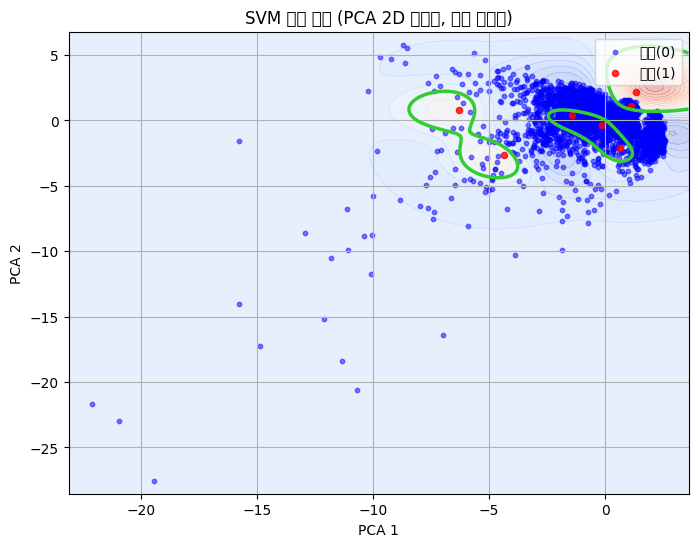

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# 1. 데이터 샘플링 (속도 유지)
sample_idx = np.random.choice(len(train_X), size=5000, replace=False)
X_sample = train_X.iloc[sample_idx]
y_sample = train_Y.iloc[sample_idx]

# 2. PCA로 2D 변환
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sample)

# 3. SVM 학습 (간단버전)
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_2d, y_sample)

# 4. 결정경계 계산
xx, yy = np.meshgrid(np.linspace(X_2d[:,0].min()-1, X_2d[:,0].max()+1, 200),
                     np.linspace(X_2d[:,1].min()-1, X_2d[:,1].max()+1, 200))
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 시각화
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.3)
plt.contour(xx, yy, Z, levels=[0], linewidths=2.5, colors='limegreen')  # 결정 경계 (초록색)

# 데이터 점
plt.scatter(X_2d[y_sample==0,0], X_2d[y_sample==0,1], c='blue', s=10, label='정상(0)', alpha=0.5)
plt.scatter(X_2d[y_sample==1,0], X_2d[y_sample==1,1], c='red', s=20, label='사기(1)', alpha=0.8)

plt.title("SVM 결정 경계 (PCA 2D 시각화, 초록 경계선)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()


8. 예측 및 평가 (Threshold = 0.5)

In [17]:
Y_predicted_probability = model.predict_proba(test_X)[:, 1]
Y_predict_value = (Y_predicted_probability > 0.5).astype(int)

precision = precision_score(test_Y, Y_predict_value)
recall = recall_score(test_Y, Y_predict_value)

print("모델 평가 결과 (SVM, threshold=0.5)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")


모델 평가 결과 (SVM, threshold=0.5)
Precision: 0.7042
Recall:    0.5102
